In [10]:
"""
=============================================================
  NSE PORTFOLIO BACKTEST — LONG + SHORT STRATEGY
  ─────────────────────────────────────────────────────────
  LONG ENTRY:
    UTBot buy signal + undervalued stock

  SHORT ENTRY:
    UTBot sell signal + overvalued stock

  VALUATION:
    Benjamin Graham + DCF + EV/FCF

  FEATURES ADDED:
    ✔ Long trades
    ✔ Short selling trades
    ✔ Separate short-selling profit tracking
    ✔ Long vs Short statistics
=============================================================
"""

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import pickle
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

# ─────────────────────────────────────────────
# SETTINGS
# ─────────────────────────────────────────────
INITIAL_CAPITAL = 100000
STOP_LOSS_PCT = 0.07
MAX_POSITIONS = 9
LOOKBACK_PERIOD = "10y"

ATR_PERIOD = 14
ATR_MULTIPLIER = 0.03
MAX_DRAWDOWN_PCT = 0.04

MIN_MARKET_CAP_CR = 1000
MAX_MARKET_CAP_CR = 100000

MIN_FCF = 0
MIN_FCF_YIELD_PCT = 1.0

DCF_DISCOUNT_RATE = 0.12
DCF_TERMINAL_GROWTH = 0.05
DCF_YEARS = 10

W_GRAHAM = 0.35
W_DCF = 0.40
W_EVFCF = 0.25

MAX_WORKERS = 20
CACHE_DIR = "cache_fcf"
USE_CACHE = True

# ─────────────────────────────────────────────
# CACHE
# ─────────────────────────────────────────────
os.makedirs(CACHE_DIR, exist_ok=True)

def cache_path(ticker):
    return os.path.join(CACHE_DIR, ticker.replace(".", "_") + ".pkl")

def load_from_cache(ticker):
    p = cache_path(ticker)

    if USE_CACHE and os.path.exists(p):
        with open(p, "rb") as f:
            return pickle.load(f)

    return None

def save_to_cache(ticker, data):

    with open(cache_path(ticker), "wb") as f:
        pickle.dump(data, f)

# ─────────────────────────────────────────────
# LOAD NSE TICKERS
# ─────────────────────────────────────────────
def load_nse_tickers():

    df = pd.read_csv("data/EQUITY_L.csv")

    symbols = (
        df["SYMBOL"]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
        .tolist()
    )

    return [s + ".NS" for s in symbols if "&" not in s]

# ─────────────────────────────────────────────
# UT BOT
# ─────────────────────────────────────────────
def compute_utbot(df):

    df = df.copy()

    df["tr"] = np.maximum(
        df["High"] - df["Low"],
        np.maximum(
            (df["High"] - df["Close"].shift()).abs(),
            (df["Low"] - df["Close"].shift()).abs()
        )
    )

    df["atr"] = df["tr"].ewm(
        span=ATR_PERIOD,
        adjust=False
    ).mean()

    df["upper"] = (
        df["Close"]
        - ATR_MULTIPLIER * df["atr"]
    )

    df["lower"] = (
        df["Close"]
        + ATR_MULTIPLIER * df["atr"]
    )

    trend = [1]

    for i in range(1, len(df)):

        if df["Close"].iloc[i] > df["lower"].iloc[i - 1]:
            trend.append(1)

        elif df["Close"].iloc[i] < df["upper"].iloc[i - 1]:
            trend.append(-1)

        else:
            trend.append(trend[-1])

    df["trend"] = trend

    df["buy"] = (
        (df["trend"] == 1)
        &
        (df["trend"].shift() == -1)
    )

    df["sell"] = (
        (df["trend"] == -1)
        &
        (df["trend"].shift() == 1)
    )

    df["volatility"] = (
        df["Close"]
        .pct_change(fill_method=None)
        .rolling(20)
        .std()
    )

    return df

# ─────────────────────────────────────────────
# FCF CHECK
# ─────────────────────────────────────────────
def check_fcf(info, cashflow_df):

    fcf = None

    if cashflow_df is not None and not cashflow_df.empty:

        try:

            ocf = None
            capex = None

            for row in [
                "Operating Cash Flow",
                "Total Cash From Operating Activities",
                "Cash Flow From Continuing Operating Activities"
            ]:

                if row in cashflow_df.index:
                    ocf = cashflow_df.loc[row].iloc[0]
                    break

            for row in [
                "Capital Expenditure",
                "Purchase Of Property Plant And Equipment",
                "Capital Expenditures"
            ]:

                if row in cashflow_df.index:
                    capex = cashflow_df.loc[row].iloc[0]
                    break

            if ocf is not None and capex is not None:
                fcf = float(ocf) + float(capex)

        except:
            pass

    if fcf is None:

        ocf = info.get("operatingCashflow")
        capex = info.get("capitalExpenditures")

        if ocf is not None and capex is not None:
            fcf = float(ocf) + float(capex)

    if fcf is None:

        fcf_raw = info.get("freeCashflow")

        if fcf_raw is not None:
            fcf = float(fcf_raw)

    if fcf is None:
        return False, None, None

    if fcf <= MIN_FCF:
        return False, fcf, None

    market_cap = info.get("marketCap")

    if not market_cap or market_cap <= 0:
        return False, fcf, None

    fcf_yield = (fcf / market_cap) * 100

    if fcf_yield < MIN_FCF_YIELD_PCT:
        return False, fcf, fcf_yield

    return True, fcf, fcf_yield

# ─────────────────────────────────────────────
# VALUATION
# ─────────────────────────────────────────────
def graham_intrinsic(eps, growth_pct):

    g = min(growth_pct, 12.0)

    return eps * (8.5 + 2 * g)

def dcf_intrinsic(fcf, shares_outstanding, growth_pct):

    if shares_outstanding <= 0 or fcf <= 0:
        return None

    g = min(growth_pct / 100, 0.20)

    r = DCF_DISCOUNT_RATE

    gT = DCF_TERMINAL_GROWTH

    pv = 0.0
    cf = fcf

    for yr in range(1, DCF_YEARS + 1):

        cf *= (1 + g)

        pv += cf / (1 + r) ** yr

    terminal_cf = cf * (1 + gT)

    terminal_pv = (
        terminal_cf / (r - gT)
    ) / (1 + r) ** DCF_YEARS

    total_pv = pv + terminal_pv

    return total_pv / shares_outstanding

def evfcf_score(ev, fcf):

    if fcf <= 0 or ev is None or ev <= 0:
        return 0.0

    ratio = ev / fcf

    if ratio <= 0:
        return 0.0

    return 1.0 / ratio

def composite_intrinsic(
    eps,
    fcf,
    shares,
    growth_pct,
    ev
):

    graham = graham_intrinsic(eps, growth_pct)

    dcf = dcf_intrinsic(
        fcf,
        shares,
        growth_pct
    )

    evfcf = evfcf_score(ev, fcf)

    if dcf is None:
        return graham, None, graham, None

    evfcf_ratio = (
        (ev / fcf)
        if fcf > 0 and ev
        else None
    )

    evfcf_boost = 1.0 + (evfcf * 2)

    composite = (
        (W_GRAHAM * graham)
        +
        (W_DCF * dcf * evfcf_boost)
        +
        (W_EVFCF * dcf)
    )

    return (
        composite,
        dcf,
        graham,
        evfcf_ratio
    )

# ─────────────────────────────────────────────
# FETCH TICKER
# ─────────────────────────────────────────────
def fetch_ticker(ticker):

    cached = load_from_cache(ticker)

    if cached is not None:
        return ticker, cached

    try:

        stock = yf.Ticker(ticker)

        info = stock.info

        market_cap = info.get("marketCap")

        if not market_cap:
            return ticker, None

        mc_cr = market_cap / 1e7

        if not (
            MIN_MARKET_CAP_CR
            <= mc_cr <=
            MAX_MARKET_CAP_CR
        ):
            return ticker, None

        eps = info.get("trailingEps")

        if eps is None or eps <= 0:
            return ticker, None

        try:
            cf_df = stock.cashflow
        except:
            cf_df = None

        fcf_ok, fcf, fcf_yield = check_fcf(
            info,
            cf_df
        )

        if not fcf_ok:
            return ticker, None

        df = stock.history(period=LOOKBACK_PERIOD)

        if df.empty or len(df) < 60:
            return ticker, None

        df = compute_utbot(df)

        growth_raw = (
            info.get("earningsQuarterlyGrowth")
            or 0.05
        )

        growth_pct = min(growth_raw * 100, 20)

        shares = (
            info.get("sharesOutstanding")
            or 1
        )

        ev = info.get("enterpriseValue")

        intrinsic, dcf_val, graham_val, evfcf_ratio = composite_intrinsic(
            eps,
            fcf,
            shares,
            growth_pct,
            ev
        )

        df["Intrinsic"] = max(intrinsic, 0)
        df["DCF"] = dcf_val if dcf_val else graham_val
        df["Graham"] = graham_val
        df["EVFCFRatio"] = evfcf_ratio
        df["FCFYield"] = fcf_yield
        df["MarketCapCr"] = mc_cr

        save_to_cache(ticker, df)

        return ticker, df

    except:
        return ticker, None

# ─────────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────────
def load_all_data(tickers):

    all_data = {}

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:

        futures = {
            ex.submit(fetch_ticker, t): t
            for t in tickers
        }

        for fut in as_completed(futures):

            ticker, df = fut.result()

            if df is not None:
                all_data[ticker] = df

    return all_data

# ─────────────────────────────────────────────
# BACKTEST
# ─────────────────────────────────────────────
def run_backtest(all_data):

    cash = float(INITIAL_CAPITAL)

    open_positions = {}

    trade_log = []

    equity_curve = []

    date_index = []

    total_short_profit = 0
    total_long_profit = 0

    all_dates = sorted(
        set(
            d
            for df in all_data.values()
            for d in df.index
        )
    )

    for current_date in all_dates:

        # ─────────────────────────────
        # EXIT POSITIONS
        # ─────────────────────────────
        for ticker in list(open_positions.keys()):

            df = all_data[ticker]

            if current_date not in df.index:
                continue

            row = df.loc[current_date]

            pos = open_positions[ticker]

            exit_trade = False

            if pos["type"] == "LONG":

                stop_price = (
                    pos["entry_price"]
                    * (1 - STOP_LOSS_PCT)
                )

                if (
                    row["Close"] <= stop_price
                    or row["sell"]
                ):
                    exit_trade = True

                    profit = (
                        (row["Close"] - pos["entry_price"])
                        * pos["shares"]
                    )

            else:

                stop_price = (
                    pos["entry_price"]
                    * (1 + STOP_LOSS_PCT)
                )

                if (
                    row["Close"] >= stop_price
                    or row["buy"]
                ):
                    exit_trade = True

                    profit = (
                        (pos["entry_price"] - row["Close"])
                        * pos["shares"]
                    )

            if exit_trade:

                cash += pos["invested"] + profit

                if pos["type"] == "SHORT":
                    total_short_profit += profit
                else:
                    total_long_profit += profit

                trade_log.append({

                    "Type": pos["type"],

                    "Stock": ticker,

                    "Entry Date": pos["entry_date"],

                    "Exit Date": current_date,

                    "Entry Price": pos["entry_price"],

                    "Exit Price": row["Close"],

                    "Profit": profit,

                    "Return %": (
                        profit / pos["invested"]
                    ) * 100
                })

                del open_positions[ticker]

        # ─────────────────────────────
        # NEW ENTRIES
        # ─────────────────────────────
        available_slots = (
            MAX_POSITIONS
            - len(open_positions)
        )

        if available_slots > 0:

            candidates = []

            for ticker, df in all_data.items():

                if ticker in open_positions:
                    continue

                if current_date not in df.index:
                    continue

                row = df.loc[current_date]

                if (
                    pd.isna(row["volatility"])
                    or row["volatility"] == 0
                ):
                    continue

                # LONG
                if (
                    row["buy"]
                    and row["Close"] < row["Intrinsic"]
                ):

                    discount = (
                        row["Intrinsic"]
                        - row["Close"]
                    ) / row["Intrinsic"]

                    score = (
                        discount
                        / row["volatility"]
                    )

                    candidates.append(
                        (
                            ticker,
                            score,
                            "LONG",
                            row
                        )
                    )

                # SHORT
                elif (
                    row["sell"]
                    and row["Close"] > row["Intrinsic"]
                ):

                    premium = (
                        row["Close"]
                        - row["Intrinsic"]
                    ) / row["Intrinsic"]

                    score = (
                        premium
                        / row["volatility"]
                    )

                    candidates.append(
                        (
                            ticker,
                            score,
                            "SHORT",
                            row
                        )
                    )

            candidates.sort(
                key=lambda x: x[1],
                reverse=True
            )

            for ticker, score, trade_type, row in candidates[:available_slots]:

                allocation = cash / (
                    MAX_POSITIONS
                    - len(open_positions)
                )

                if allocation <= 0:
                    break

                shares = allocation / row["Close"]

                cash -= allocation

                open_positions[ticker] = {

                    "type": trade_type,

                    "entry_date": current_date,

                    "entry_price": row["Close"],

                    "shares": shares,

                    "invested": allocation
                }

        # ─────────────────────────────
        # DAILY EQUITY
        # ─────────────────────────────
        pv = cash

        for ticker, pos in open_positions.items():

            df = all_data[ticker]

            if current_date in df.index:

                current_price = (
                    df.loc[current_date]["Close"]
                )

                if pos["type"] == "LONG":

                    pv += (
                        pos["shares"]
                        * current_price
                    )

                else:

                    unrealized = (
                        (
                            pos["entry_price"]
                            - current_price
                        )
                        * pos["shares"]
                    )

                    pv += (
                        pos["invested"]
                        + unrealized
                    )

        equity_curve.append(pv)

        date_index.append(current_date)

    return (
        pd.DataFrame(trade_log),
        equity_curve,
        date_index,
        total_long_profit,
        total_short_profit
    )

# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────
if __name__ == "__main__":

    print("\nLoading NSE stocks...\n")

    tickers = load_nse_tickers()

    print("Total NSE Stocks:", len(tickers))

    all_data = load_all_data(tickers)

    print("Filtered Stocks:", len(all_data))

    (
        trades,
        equity_curve,
        date_index,
        long_profit,
        short_profit
    ) = run_backtest(all_data)

    # ─────────────────────────────
    # RESULTS
    # ─────────────────────────────
    final_capital = equity_curve[-1]

    print("\n==============================")
    print("FINAL RESULTS")
    print("==============================")

    print("Initial Capital:", INITIAL_CAPITAL)

    print("Final Capital:", round(final_capital, 2))

    print(
        "Total Return %:",
        round(
            (
                (final_capital / INITIAL_CAPITAL)
                - 1
            ) * 100,
            2
        )
    )

    print("\nTotal Trades:", len(trades))

    print(
        "\nProfit From LONG Trades:",
        round(long_profit, 2)
    )

    print(
        "Profit From SHORT Trades:",
        round(short_profit, 2)
    )

    if not trades.empty:

        print(
            "\nLONG Trades:",
            len(trades[trades["Type"] == "LONG"])
        )

        print(
            "SHORT Trades:",
            len(trades[trades["Type"] == "SHORT"])
        )

        trades["Cumulative Profit"] = (
            trades["Profit"].cumsum()
        )

        trades["Equity"] = (
            INITIAL_CAPITAL
            + trades["Cumulative Profit"]
        )

        # Excel timezone fix
        for col in trades.select_dtypes(
            include=["datetimetz"]
        ).columns:

            trades[col] = trades[col].dt.tz_localize(None)

        trades.to_excel(
            "long_short_trade_log.xlsx",
            index=False
        )

        print(
            "\nTrade log saved: long_short_trade_log.xlsx"
        )

    # ─────────────────────────────
    # EQUITY CURVE
    # ─────────────────────────────
    plt.figure(figsize=(14, 6))

    plt.plot(
        date_index,
        equity_curve
    )

    plt.title("Long + Short Portfolio Equity Curve")

    plt.xlabel("Date")

    plt.ylabel("Portfolio Value")

    plt.grid(True)

    plt.show()


Loading NSE stocks...

Total NSE Stocks: 2224


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ARISINFRA.NS"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: LTIM.NS"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Cru

Filtered Stocks: 528


TypeError: Cannot compare tz-naive and tz-aware timestamps

Total NSE tickers: 2224
Fetching 2224 tickers with 20 workers...



HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ARISINFRA.NS"}}}


  [200/2224]  loaded: 48  |  ETA: 1.8 min
  [400/2224]  loaded: 103  |  ETA: 1.3 min
  [600/2224]  loaded: 158  |  ETA: 1.1 min
  [800/2224]  loaded: 212  |  ETA: 0.9 min


HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"err

  [1000/2224]  loaded: 285  |  ETA: 0.7 min


...

  [2000/2224]  loaded: 487  |  ETA: 0.1 min


HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"User is unable to access this feature - https://bit.ly/yahoo-finance-api-feedback"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","descriptio

  [2200/2224]  loaded: 530  |  ETA: 0.0 min


HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}


  [2224/2224]  loaded: 533  |  ETA: 0.0 min

Loaded 533 stocks in 1.3 min

Running backtest over 2475 trading days...


Total Short Profit: -106037.71

Total Trades: 6970
Final Capital: 0.0
Total Return %: -100.0
Saved: trade_log_long_short.xlsx

── RESULTS ──────────────────────
Win Rate    : 37.0%
Avg Win     : ₹200
Avg Loss    : ₹-118
Risk/Reward : 1.70

By Type:
       Profit  Return %
Type                   
LONG    43.33      1.25
SHORT  -23.66     -0.64

Exit Reasons:
Exit Reason
UT Buy Cover    4482
Long ATR        1235
UT Sell          950
Long Stop        303
Name: count, dtype: int64


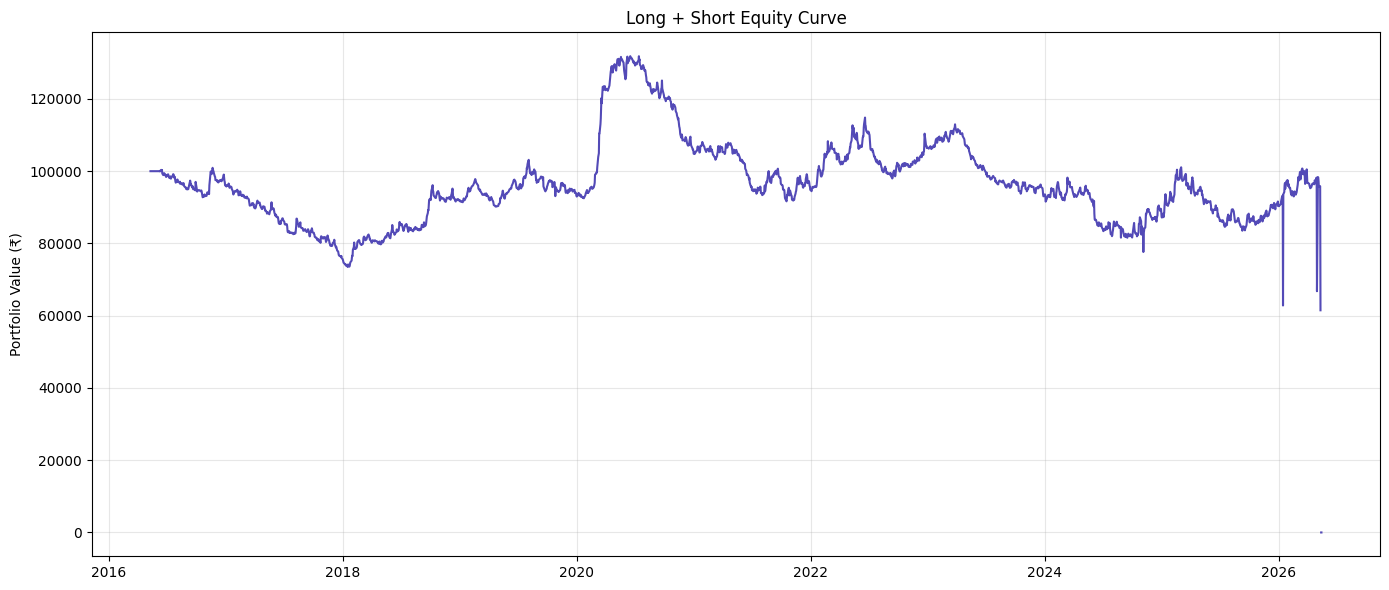

In [1]:
"""
=============================================================
  NSE PORTFOLIO BACKTEST — LONG + SHORT SYSTEM
  ─────────────────────────────────────────────────────────
  LONGS:
    • UT Bot Buy Signal
    • Undervalued vs Intrinsic
    • Positive FCF
    • Graham + DCF + EV/FCF valuation

  SHORTS:
    • UT Bot Sell Signal ONLY
    • No valuation filter for shorts

=============================================================
"""

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import pickle
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

# ─────────────────────────────────────────────
# SETTINGS
# ─────────────────────────────────────────────
INITIAL_CAPITAL   = 100_000
STOP_LOSS_PCT     = 0.04
MAX_POSITIONS     = 30
LOOKBACK_PERIOD   = "10y"

ATR_PERIOD        = 14
ATR_MULTIPLIER    = 0.2
MAX_DRAWDOWN_PCT  = 0.2

MIN_MARKET_CAP_CR = 1_000
MAX_MARKET_CAP_CR = 100_000

MIN_FCF           = 0
MIN_FCF_YIELD_PCT = 1.0

DCF_DISCOUNT_RATE   = 0.12
DCF_TERMINAL_GROWTH = 0.05
DCF_YEARS           = 10

W_GRAHAM = 0.35
W_DCF    = 0.40
W_EVFCF  = 0.25

MAX_WORKERS = 20
CACHE_DIR   = "cache_fcf"
USE_CACHE   = True

os.makedirs(CACHE_DIR, exist_ok=True)

# ─────────────────────────────────────────────
# CACHE
# ─────────────────────────────────────────────
def cache_path(ticker):
    return os.path.join(CACHE_DIR, ticker.replace(".", "_") + ".pkl")

def load_from_cache(ticker):
    p = cache_path(ticker)
    if USE_CACHE and os.path.exists(p):
        with open(p, "rb") as f:
            return pickle.load(f)
    return None

def save_to_cache(ticker, data):
    with open(cache_path(ticker), "wb") as f:
        pickle.dump(data, f)

# ─────────────────────────────────────────────
# TIMEZONE FIX
# ─────────────────────────────────────────────
def normalize_index(df):
    """Strip timezone and floor to midnight so date lookups work correctly."""
    idx = df.index
    if hasattr(idx, "tz") and idx.tz is not None:
        idx = idx.tz_convert("UTC").tz_localize(None)
    df.index = idx.normalize()
    return df

# ─────────────────────────────────────────────
# LOAD NSE TICKERS
# ─────────────────────────────────────────────
def load_nse_tickers():
    df = pd.read_csv("data/EQUITY_L.csv")
    symbols = (
        df["SYMBOL"]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
        .tolist()
    )
    return [s + ".NS" for s in symbols if "&" not in s]

# ─────────────────────────────────────────────
# UT BOT
# ─────────────────────────────────────────────
def compute_utbot(df):
    df = df.copy()
    df["tr"] = np.maximum(
        df["High"] - df["Low"],
        np.maximum(
            (df["High"] - df["Close"].shift()).abs(),
            (df["Low"] - df["Close"].shift()).abs()
        )
    )
    df["atr"]   = df["tr"].ewm(span=ATR_PERIOD, adjust=False).mean()
    df["upper"] = df["Close"] - ATR_MULTIPLIER * df["atr"]
    df["lower"] = df["Close"] + ATR_MULTIPLIER * df["atr"]

    trend = [1]
    for i in range(1, len(df)):
        if df["Close"].iloc[i] > df["lower"].iloc[i - 1]:
            trend.append(1)
        elif df["Close"].iloc[i] < df["upper"].iloc[i - 1]:
            trend.append(-1)
        else:
            trend.append(trend[-1])

    df["trend"]      = trend
    df["buy"]        = (df["trend"] == 1)  & (df["trend"].shift() == -1)
    df["sell"]       = (df["trend"] == -1) & (df["trend"].shift() == 1)
    df["volatility"] = df["Close"].pct_change(fill_method=None).rolling(20).std()
    return df

# ─────────────────────────────────────────────
# FCF FILTER
# ─────────────────────────────────────────────
def check_fcf(info, cashflow_df):
    fcf = None

    if cashflow_df is not None and not cashflow_df.empty:
        try:
            ocf, capex = None, None
            for row in [
                "Operating Cash Flow",
                "Total Cash From Operating Activities",
                "Cash Flow From Continuing Operating Activities"
            ]:
                if row in cashflow_df.index:
                    ocf = cashflow_df.loc[row].iloc[0]
                    break
            for row in [
                "Capital Expenditure",
                "Purchase Of Property Plant And Equipment",
                "Capital Expenditures"
            ]:
                if row in cashflow_df.index:
                    capex = cashflow_df.loc[row].iloc[0]
                    break
            if ocf is not None and capex is not None:
                fcf = float(ocf) + float(capex)
        except:
            pass

    if fcf is None:
        ocf   = info.get("operatingCashflow")
        capex = info.get("capitalExpenditures")
        if ocf is not None and capex is not None:
            fcf = float(ocf) + float(capex)

    if fcf is None:
        fcf_raw = info.get("freeCashflow")
        if fcf_raw is not None:
            fcf = float(fcf_raw)

    if fcf is None:
        return False, None, None

    if fcf <= MIN_FCF:
        return False, fcf, None

    market_cap = info.get("marketCap")
    if not market_cap or market_cap <= 0:
        return False, fcf, None

    fcf_yield = (fcf / market_cap) * 100

    if fcf_yield < MIN_FCF_YIELD_PCT:
        return False, fcf, fcf_yield

    return True, fcf, fcf_yield

# ─────────────────────────────────────────────
# VALUATION
# ─────────────────────────────────────────────
def graham_intrinsic(eps, growth_pct):
    g = min(growth_pct, 12.0)
    return eps * (8.5 + 2 * g)

def dcf_intrinsic(fcf, shares_outstanding, growth_pct):
    if shares_outstanding <= 0 or fcf <= 0:
        return None
    g  = min(growth_pct / 100, 0.20)
    r  = DCF_DISCOUNT_RATE
    gT = DCF_TERMINAL_GROWTH
    pv, cf = 0.0, fcf
    for yr in range(1, DCF_YEARS + 1):
        cf *= (1 + g)
        pv += cf / (1 + r) ** yr
    terminal_pv = (cf * (1 + gT) / (r - gT)) / (1 + r) ** DCF_YEARS
    return max((pv + terminal_pv) / shares_outstanding, 0)

def evfcf_score(ev, fcf):
    if fcf <= 0 or ev is None or ev <= 0:
        return 0.0
    ratio = ev / fcf
    return 1.0 / ratio if ratio > 0 else 0.0

def composite_intrinsic(eps, fcf, shares, growth_pct, ev):
    graham    = graham_intrinsic(eps, growth_pct)
    dcf       = dcf_intrinsic(fcf, shares, growth_pct)
    evfcf     = evfcf_score(ev, fcf)

    if dcf is None:
        return graham, None, graham, None

    evfcf_ratio = (ev / fcf) if fcf > 0 and ev else None
    evfcf_boost = 1.0 + (evfcf * 2)
    composite   = (
        (W_GRAHAM * graham)
        + (W_DCF * dcf * evfcf_boost)
        + (W_EVFCF * dcf)
    )
    return composite, dcf, graham, evfcf_ratio

# ─────────────────────────────────────────────
# FETCH TICKER
# ─────────────────────────────────────────────
def fetch_ticker(ticker):
    cached = load_from_cache(ticker)
    if cached is not None:
        return ticker, cached

    try:
        stock      = yf.Ticker(ticker)
        info       = stock.info
        market_cap = info.get("marketCap")

        if not market_cap:
            return ticker, None

        mc_cr = market_cap / 1e7
        if not (MIN_MARKET_CAP_CR <= mc_cr <= MAX_MARKET_CAP_CR):
            return ticker, None

        eps = info.get("trailingEps")
        if eps is None or eps <= 0:
            return ticker, None

        try:
            cf_df = stock.cashflow
        except:
            cf_df = None

        fcf_ok, fcf, fcf_yield = check_fcf(info, cf_df)
        if not fcf_ok:
            return ticker, None

        df = stock.history(period=LOOKBACK_PERIOD)
        if df.empty or len(df) < 60:
            return ticker, None

        df = compute_utbot(df)
        df = normalize_index(df)          # ← FIX: strip timezone

        growth_raw = info.get("earningsQuarterlyGrowth") or 0.05
        growth_pct = min(growth_raw * 100, 20.0)
        shares     = info.get("sharesOutstanding") or 1
        ev         = info.get("enterpriseValue")

        intrinsic, dcf_val, graham_val, evfcf_ratio = composite_intrinsic(
            eps, fcf, shares, growth_pct, ev
        )

        df["Intrinsic"]  = max(intrinsic, 0)
        df["DCF"]        = dcf_val if dcf_val else graham_val
        df["Graham"]     = graham_val
        df["EVFCFRatio"] = evfcf_ratio if evfcf_ratio else np.nan
        df["FCF"]        = fcf
        df["FCFYield"]   = fcf_yield
        df["MarketCapCr"] = mc_cr
        df["GrowthPct"]  = growth_pct

        save_to_cache(ticker, df)
        return ticker, df

    except:
        return ticker, None

# ─────────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────────
def load_all_data(tickers):
    all_data = {}
    print(f"Fetching {len(tickers)} tickers with {MAX_WORKERS} workers...\n")
    t0 = time.time()

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        futures = {ex.submit(fetch_ticker, t): t for t in tickers}
        done = 0
        for fut in as_completed(futures):
            ticker, df = fut.result()
            done += 1
            if df is not None:
                all_data[ticker] = df
            if done % 200 == 0 or done == len(tickers):
                elapsed = time.time() - t0
                eta = (elapsed / done) * (len(tickers) - done)
                print(f"  [{done}/{len(tickers)}]  loaded: {len(all_data)}  |  ETA: {eta/60:.1f} min")

    print(f"\nLoaded {len(all_data)} stocks in {(time.time()-t0)/60:.1f} min\n")
    return all_data

# ─────────────────────────────────────────────
# BACKTEST
# ─────────────────────────────────────────────
def run_backtest(all_data):
    cash               = float(INITIAL_CAPITAL)
    open_positions     = {}
    trade_log          = []
    equity_curve       = []
    date_index         = []
    short_profit_total = 0

    # Normalize all indices (safety net in case cache has tz-aware data)
    for ticker in list(all_data.keys()):
        all_data[ticker] = normalize_index(all_data[ticker])

    all_dates = sorted(set(d for df in all_data.values() for d in df.index))
    print(f"Running backtest over {len(all_dates)} trading days...\n")

    for current_date in all_dates:

        # ─────────────────────────────
        # EXIT POSITIONS
        # ─────────────────────────────
        for ticker in list(open_positions.keys()):
            df  = all_data[ticker]
            if current_date not in df.index:
                continue

            row            = df.loc[current_date]
            pos            = open_positions[ticker]
            position_type  = pos["type"]
            exit_trade     = False
            exit_reason    = None
            exit_price     = None
            profit         = 0.0

            # ── LONG ──────────────────
            if position_type == "LONG":
                pos["highest_price"] = max(pos["highest_price"], float(row["Close"]))

                stop_price = pos["entry_price"] * (1 - STOP_LOSS_PCT)
                atr_stop   = pos["highest_price"] - float(row["atr"])
                drawdown   = (pos["highest_price"] - float(row["Close"])) / pos["highest_price"]

                if   float(row["Close"]) <= stop_price:    exit_reason = "Long Stop"
                elif float(row["Close"]) <= atr_stop:      exit_reason = "Long ATR"
                elif drawdown >= MAX_DRAWDOWN_PCT:          exit_reason = "Long DD"
                elif bool(row["sell"]):                    exit_reason = "UT Sell"

                if exit_reason:
                    exit_trade = True
                    exit_price = float(row["Close"])
                    proceeds   = pos["shares"] * exit_price
                    profit     = proceeds - pos["invested"]
                    cash      += proceeds

            # ── SHORT ─────────────────
            else:
                if bool(row["buy"]):
                    exit_trade  = True
                    exit_reason = "UT Buy Cover"
                    exit_price  = float(row["Close"])
                    profit      = (pos["entry_price"] - exit_price) * pos["shares"]
                    cash       += pos["invested"] + profit
                    short_profit_total += profit

            # ── LOG TRADE ─────────────
            if exit_trade and exit_price is not None:
                if position_type == "SHORT":
                    ret = ((pos["entry_price"] - exit_price) / pos["entry_price"]) * 100
                else:
                    ret = ((exit_price / pos["entry_price"]) - 1) * 100

                trade_log.append({
                    "Stock":       ticker,
                    "Type":        position_type,
                    "Entry Date":  pos["entry_date"],
                    "Exit Date":   current_date,
                    "Entry Price": round(pos["entry_price"], 2),
                    "Exit Price":  round(exit_price, 2),
                    "Profit":      round(profit, 2),
                    "Return %":    round(ret, 2),
                    "Exit Reason": exit_reason,
                })
                del open_positions[ticker]

        # ─────────────────────────────
        # ENTRY
        # ─────────────────────────────
        available_slots = MAX_POSITIONS - len(open_positions)

        if available_slots > 0 and cash > 0:
            candidates = []

            for ticker, df in all_data.items():
                if ticker in open_positions:
                    continue
                if current_date not in df.index:
                    continue

                row = df.loc[current_date]

                if pd.isna(row["volatility"]) or row["volatility"] == 0:
                    continue

                # LONG
                if bool(row["buy"]) and float(row["Close"]) < float(row["Intrinsic"]):
                    discount = (float(row["Intrinsic"]) - float(row["Close"])) / float(row["Intrinsic"])
                    score    = discount / float(row["volatility"])
                    candidates.append((ticker, "LONG", score, row))

                # SHORT
                elif bool(row["sell"]):
                    score = 1.0 / float(row["volatility"])
                    candidates.append((ticker, "SHORT", score, row))

            candidates.sort(key=lambda x: x[2], reverse=True)

            for ticker, typ, score, row in candidates[:available_slots]:
                remaining = MAX_POSITIONS - len(open_positions)
                if remaining <= 0 or cash <= 0:
                    break

                allocation = cash / remaining
                shares     = allocation / float(row["Close"])
                cash      -= allocation

                open_positions[ticker] = {
                    "type":          typ,
                    "entry_date":    current_date,
                    "entry_price":   float(row["Close"]),
                    "highest_price": float(row["Close"]),
                    "shares":        shares,
                    "invested":      allocation,
                }

        # ─────────────────────────────
        # DAILY EQUITY
        # ─────────────────────────────
        pv = cash
        for ticker, pos in open_positions.items():
            df = all_data[ticker]
            if current_date in df.index:
                price = float(df.loc[current_date]["Close"])
                if pos["type"] == "LONG":
                    pv += pos["shares"] * price
                else:
                    unrealized = (pos["entry_price"] - price) * pos["shares"]
                    pv += pos["invested"] + unrealized

        equity_curve.append(pv)
        date_index.append(current_date)

    print("\nTotal Short Profit:", round(short_profit_total, 2))
    return pd.DataFrame(trade_log), equity_curve, date_index

# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────
if __name__ == "__main__":

    tickers  = load_nse_tickers()
    print("Total NSE tickers:", len(tickers))

    all_data = load_all_data(tickers)

    trades, equity_curve, date_index = run_backtest(all_data)

    print("\nTotal Trades:", len(trades))

    if not equity_curve:
        print("ERROR: equity_curve is empty. Check timezone normalization.")
    else:
        final_capital = equity_curve[-1]
        print("Final Capital:", round(final_capital, 2))
        print("Total Return %:", round((final_capital / INITIAL_CAPITAL - 1) * 100, 2))

    if not trades.empty:
        trades = trades.sort_values("Exit Date").copy()
        trades["Cumulative Profit"] = trades["Profit"].cumsum()
        trades["Equity"]            = INITIAL_CAPITAL + trades["Cumulative Profit"]

        # ── FIX: strip timezone before saving to Excel ──
        for col in ["Entry Date", "Exit Date"]:
            if col in trades.columns:
                trades[col] = pd.to_datetime(trades[col])
                if trades[col].dt.tz is not None:
                    trades[col] = trades[col].dt.tz_localize(None)

        try:
            trades.to_excel("trade_log_long_short.xlsx", index=False)
            print("Saved: trade_log_long_short.xlsx")
        except ImportError:
            trades.to_csv("trade_log_long_short.csv", index=False)
            print("Saved: trade_log_long_short.csv")

        # ── SUMMARY ──
        wins     = trades[trades["Profit"] > 0]
        losses   = trades[trades["Profit"] < 0]
        win_rate = len(wins) / len(trades) if len(trades) > 0 else 0
        avg_win  = wins["Profit"].mean()   if len(wins)   > 0 else 0
        avg_loss = losses["Profit"].mean() if len(losses) > 0 else 0

        print("\n── RESULTS ──────────────────────")
        print(f"Win Rate    : {win_rate*100:.1f}%")
        print(f"Avg Win     : ₹{avg_win:,.0f}")
        print(f"Avg Loss    : ₹{avg_loss:,.0f}")
        if avg_loss != 0:
            print(f"Risk/Reward : {abs(avg_win/avg_loss):.2f}")
        print("\nBy Type:")
        print(trades.groupby("Type")[["Profit","Return %"]].mean().round(2))
        print("\nExit Reasons:")
        print(trades["Exit Reason"].value_counts())

    if equity_curve:
        plt.figure(figsize=(14, 6))
        plt.plot(date_index, equity_curve, color="#534AB7", lw=1.5)
        plt.title("Long + Short Equity Curve")
        plt.ylabel("Portfolio Value (₹)")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()